# Bài 1.2.2 — Trực quan hóa dữ liệu: Phân loại chất lượng Rượu đỏ
**Học phần:** Phân tích khám phá dữ liệu (EDA) — Trường Đại học Sài Gòn

**Yêu cầu:** Thực hiện trực quan hóa dữ liệu trên tập dữ liệu *Red Wine Quality*.

**Mục tiêu:** Dùng Pandas, Matplotlib, Seaborn để khám phá đặc điểm dữ liệu, phát hiện phân bố – ngoại lai – mối quan hệ giữa các biến hóa lý và điểm chất lượng `quality`.

## 1. Nạp thư viện và dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
WINE, GOLD, TEAL = "#7a1f2b", "#c9a35a", "#3f6f6b"

# File winequality-red.csv để cùng thư mục với notebook. Bộ dữ liệu UCI dùng dấu ';' phân tách.
wine = pd.read_csv("winequality-red.csv", sep=";")
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Xem nhanh cấu trúc dữ liệu
print("Kích thước (dòng, cột):", wine.shape)
wine.info()

Kích thước (dòng, cột): (1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 2. Thống kê mô tả nhanh

In [3]:
wine.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


## 3. Làm sạch dữ liệu
Kiểm tra giá trị thiếu và dòng trùng lặp trước khi trực quan hóa.

In [4]:
print("Số giá trị thiếu mỗi cột:")
print(wine.isnull().sum())
print("\nTổng dòng trùng lặp:", wine.duplicated().sum())

wine = wine.drop_duplicates().reset_index(drop=True)
print("Kích thước sau khi loại trùng:", wine.shape)

Số giá trị thiếu mỗi cột:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Tổng dòng trùng lặp: 240
Kích thước sau khi loại trùng: (1359, 12)


## 4. Phân tích đơn biến — Biến mục tiêu `quality`
### 4.1. Bar chart bằng Matplotlib

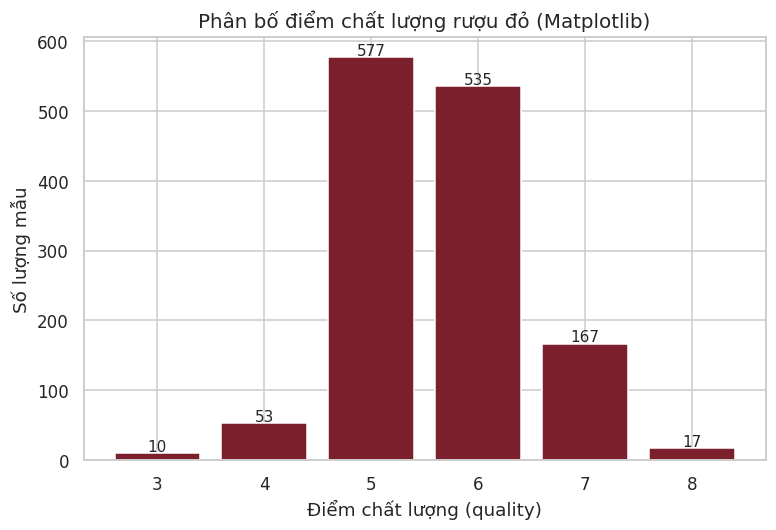

In [5]:
quality_counts = wine["quality"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(quality_counts.index, quality_counts.values, color=WINE, edgecolor="white")
plt.title("Phân bố điểm chất lượng rượu đỏ (Matplotlib)")
plt.xlabel("Điểm chất lượng (quality)")
plt.ylabel("Số lượng mẫu")
for x, y in zip(quality_counts.index, quality_counts.values):
    plt.text(x, y+3, str(y), ha="center", fontsize=10)
plt.show()

### 4.2. Bar chart bằng Seaborn (countplot)

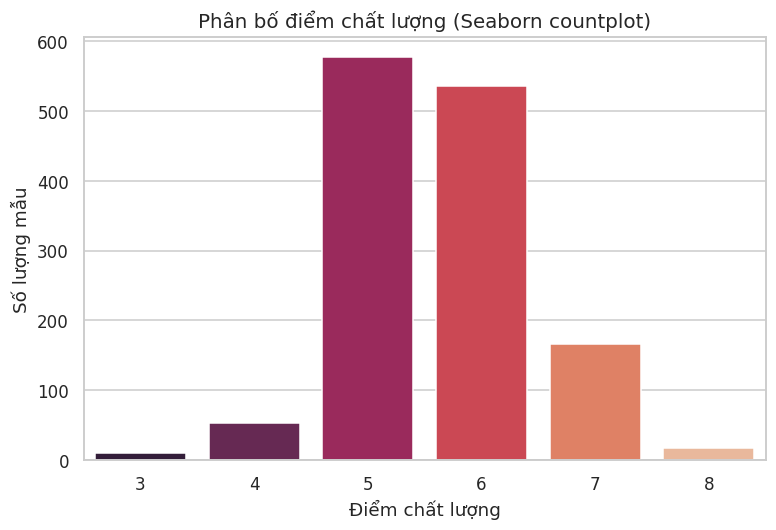

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=wine, x="quality", palette="rocket")
plt.title("Phân bố điểm chất lượng (Seaborn countplot)")
plt.xlabel("Điểm chất lượng"); plt.ylabel("Số lượng mẫu")
plt.show()

> **Nhận xét:** Dữ liệu mất cân bằng mạnh — điểm 5 và 6 chiếm đa số, điểm 3 và 8 rất hiếm.

## 5. Phân phối các biến hóa lý — Histogram
### 5.1. Histogram tổng quan cho toàn bộ biến

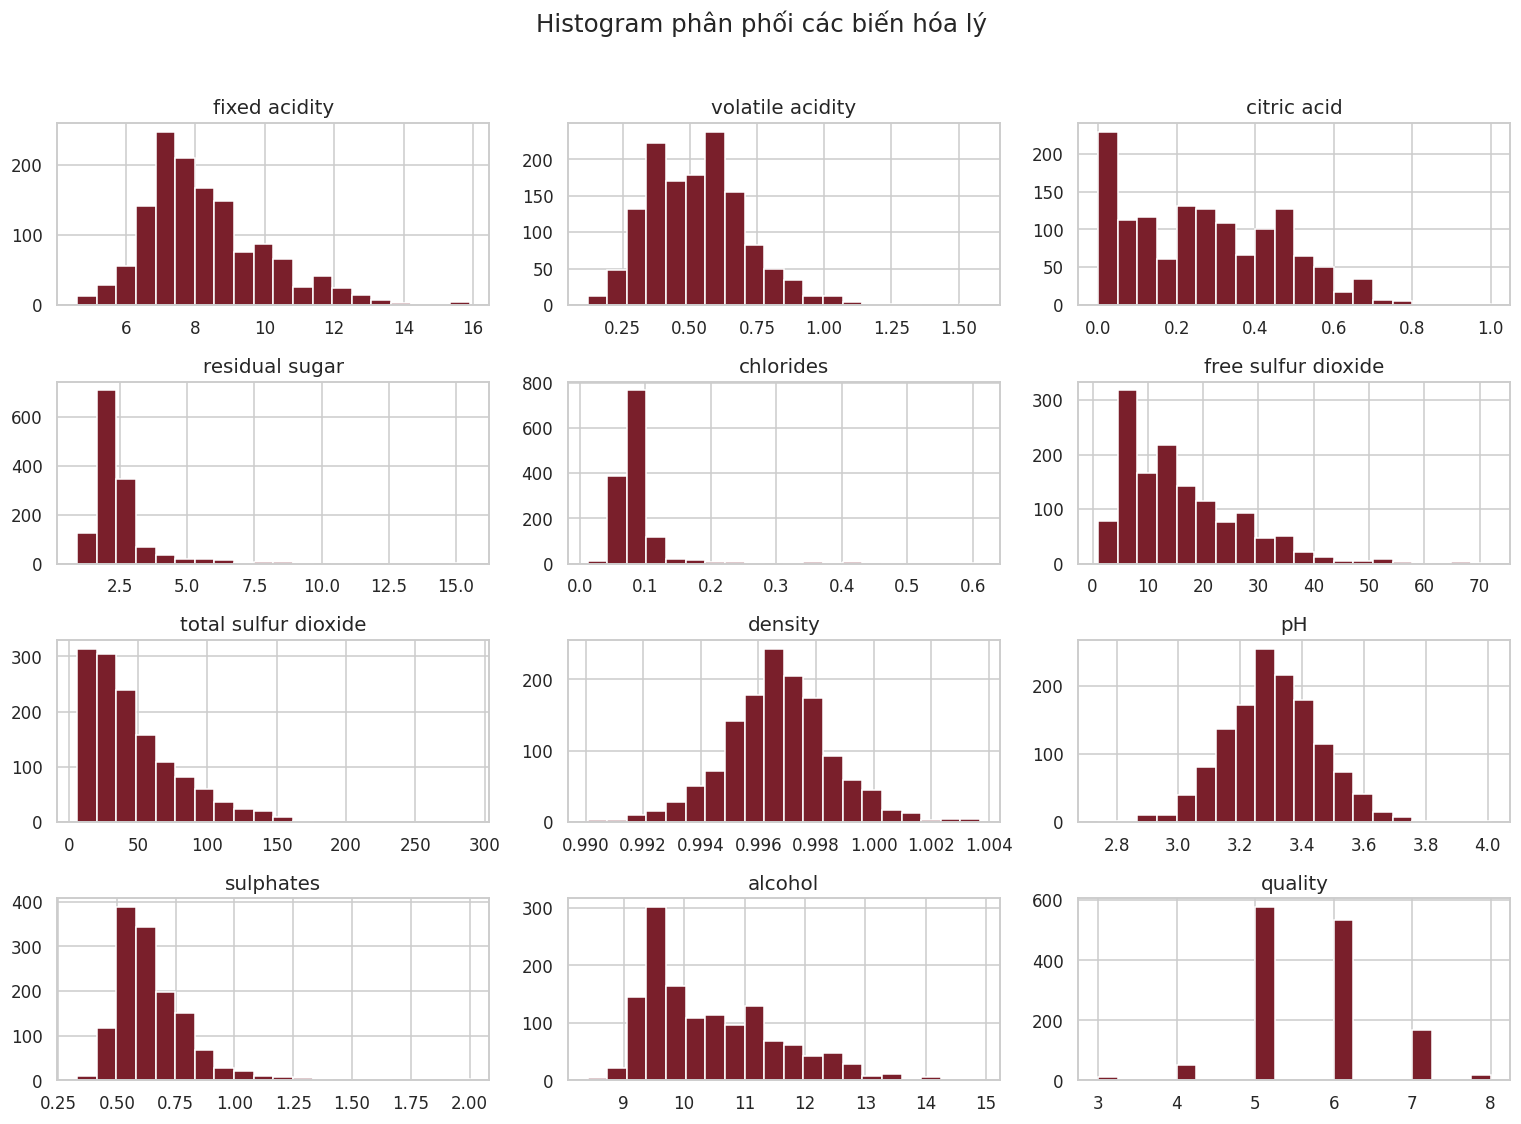

In [7]:
wine.hist(figsize=(14,10), bins=20, color=WINE, edgecolor="white")
plt.suptitle("Histogram phân phối các biến hóa lý", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.2. Histogram chi tiết kèm đường mật độ (KDE) — biến `alcohol`

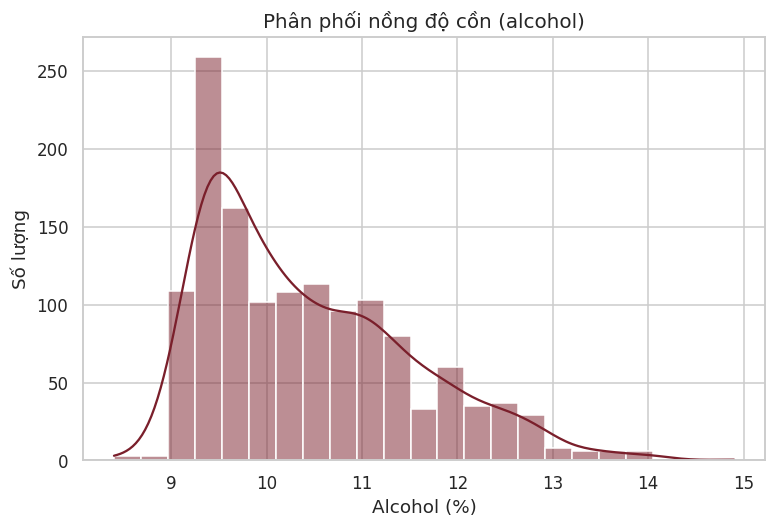

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(wine["alcohol"], kde=True, color=WINE)
plt.title("Phân phối nồng độ cồn (alcohol)")
plt.xlabel("Alcohol (%)"); plt.ylabel("Số lượng")
plt.show()

> **Nhận xét:** `alcohol` lệch phải (right-skewed); phần lớn rượu có nồng độ cồn 9–11%.

## 6. Phát hiện giá trị ngoại lai — Boxplot
### 6.1. Boxplot cho từng biến

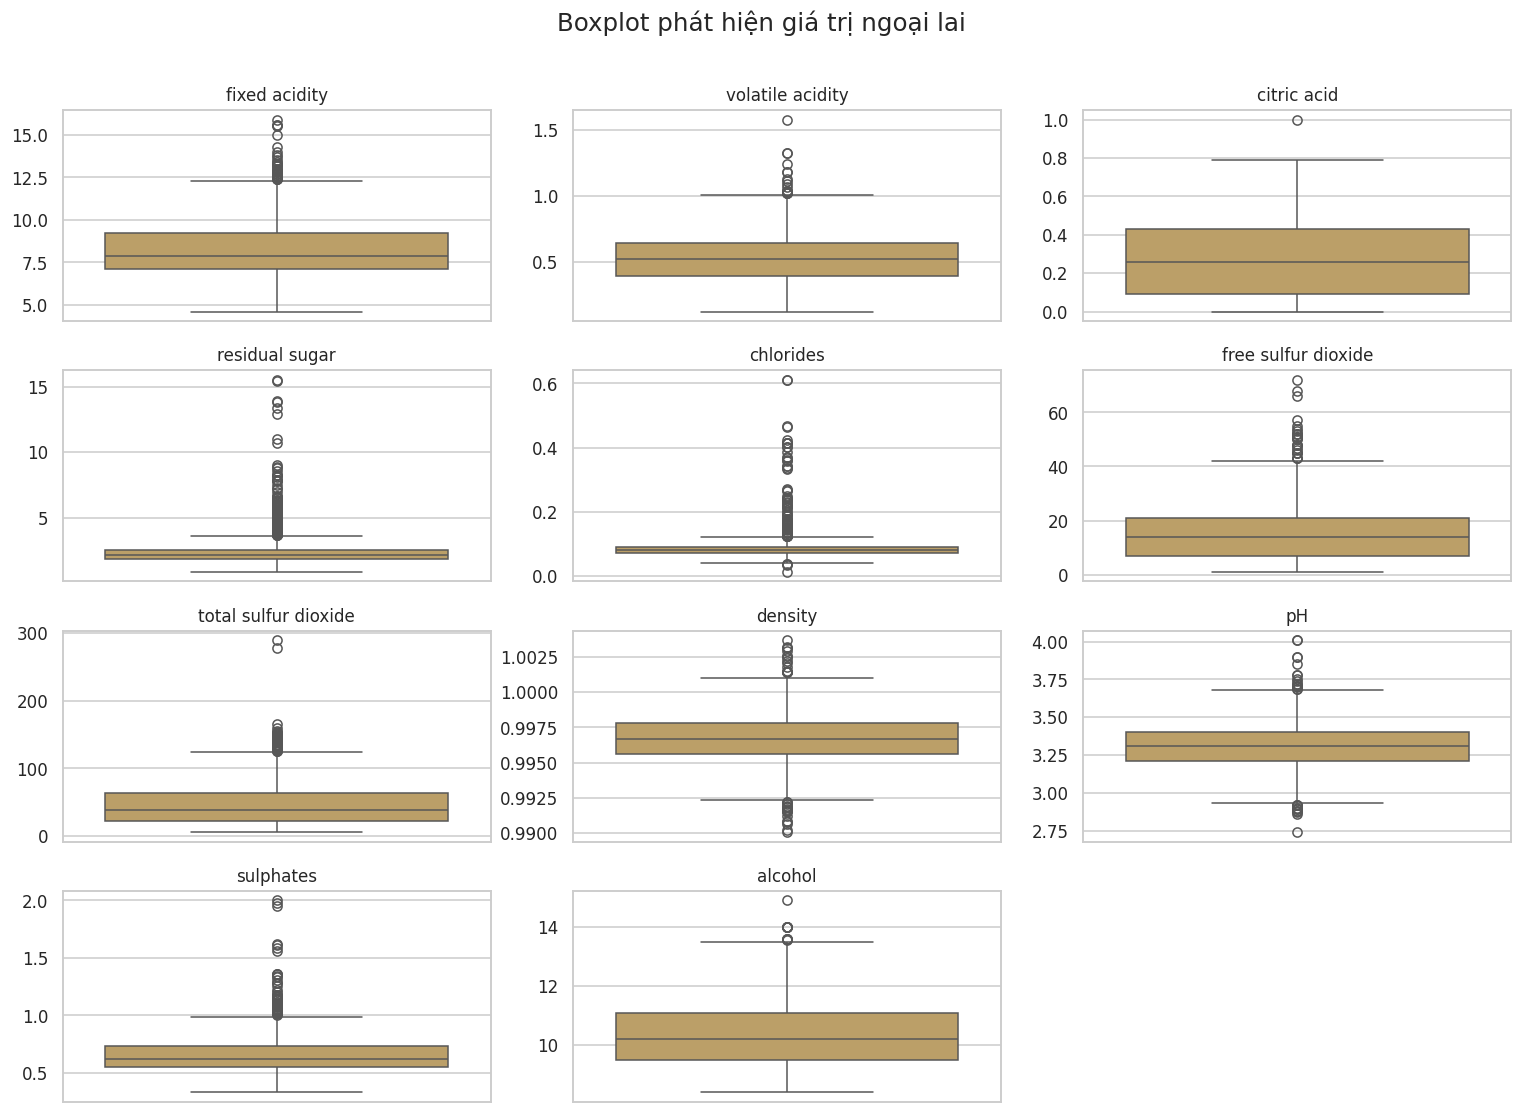

In [9]:
features = [c for c in wine.columns if c != "quality"]
plt.figure(figsize=(14,10))
for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=wine[col], color=GOLD)
    plt.title(col, fontsize=11); plt.ylabel("")
plt.suptitle("Boxplot phát hiện giá trị ngoại lai", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

> **Nhận xét:** Nhiều biến có ngoại lai rõ (`residual sugar`, `chlorides`, `total sulfur dioxide`, `sulphates`).

### 6.2. Boxplot hai chiều — `alcohol` theo từng điểm chất lượng

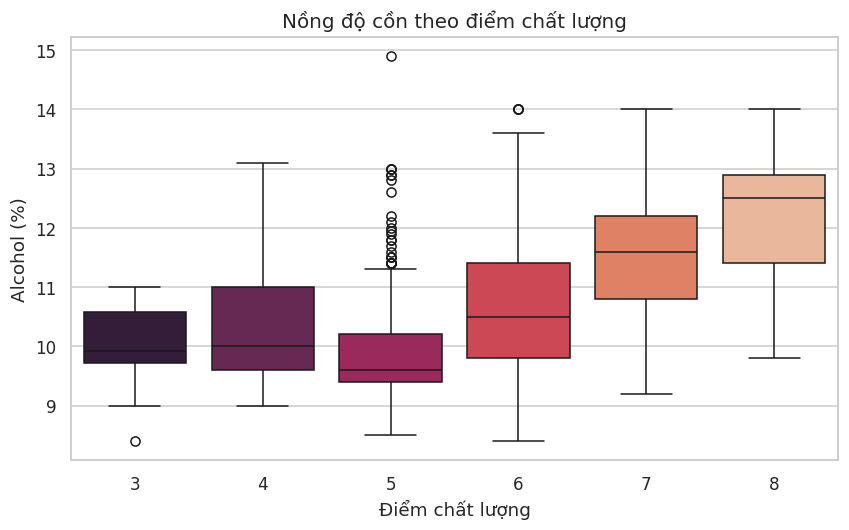

In [10]:
plt.figure(figsize=(9,5))
sns.boxplot(data=wine, x="quality", y="alcohol", palette="rocket")
plt.title("Nồng độ cồn theo điểm chất lượng")
plt.xlabel("Điểm chất lượng"); plt.ylabel("Alcohol (%)")
plt.show()

> **Nhận xét:** Điểm chất lượng càng cao thì nồng độ cồn trung bình càng tăng.

## 7. Quan hệ giữa các biến — Scatter plot

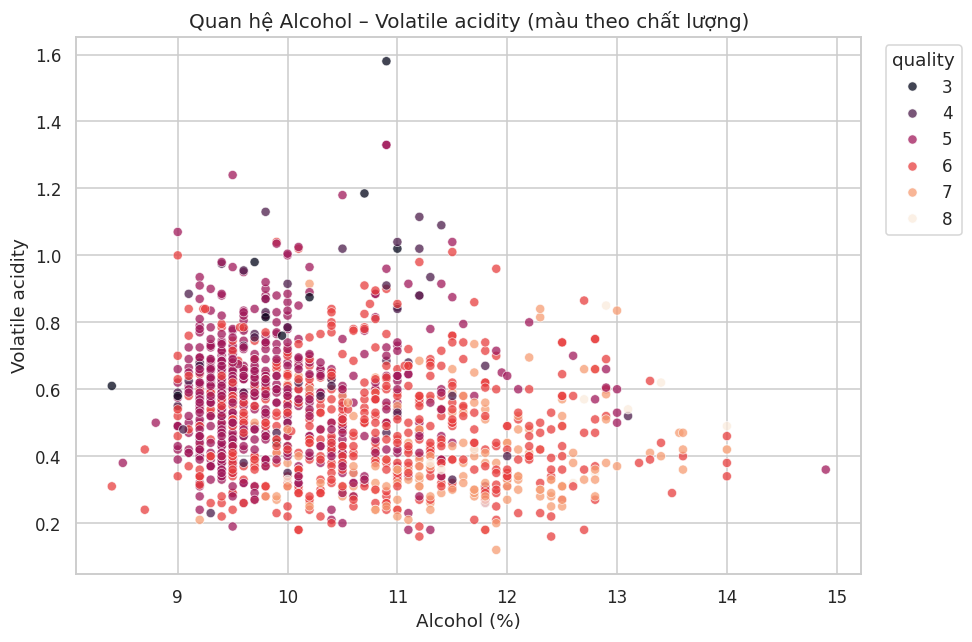

In [11]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=wine, x="alcohol", y="volatile acidity",
                hue="quality", palette="rocket", alpha=0.75)
plt.title("Quan hệ Alcohol – Volatile acidity (màu theo chất lượng)")
plt.xlabel("Alcohol (%)"); plt.ylabel("Volatile acidity")
plt.legend(title="quality", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Ma trận tương quan — Heatmap

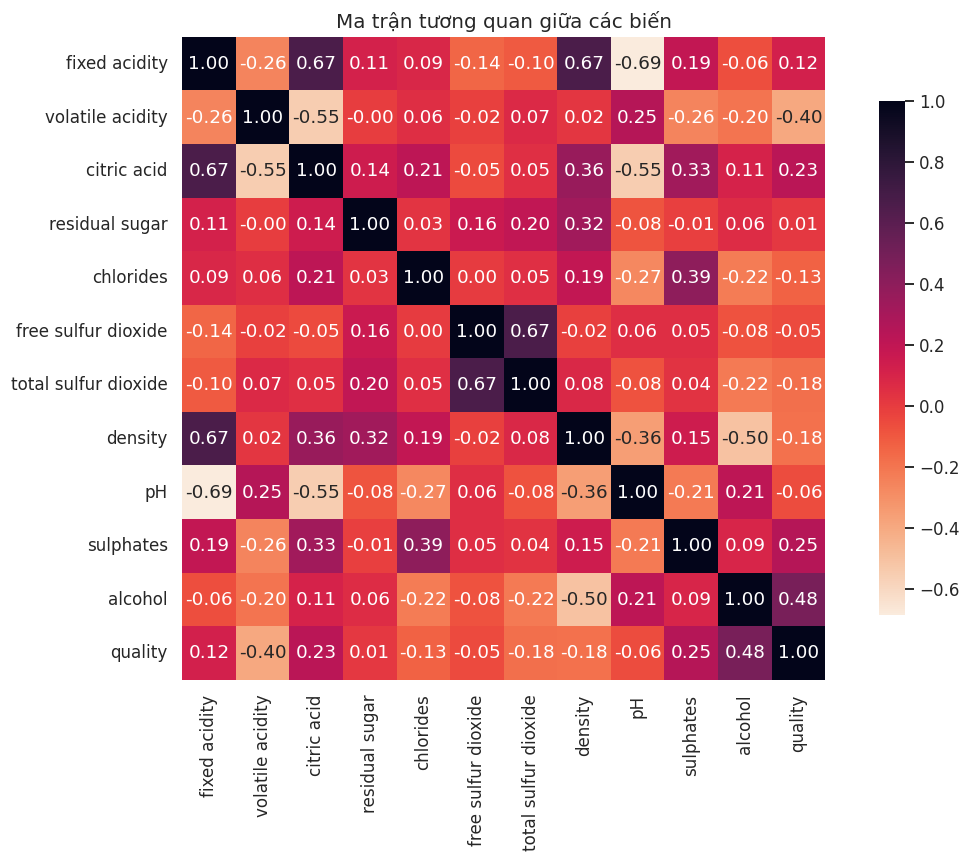

In [12]:
plt.figure(figsize=(11,8))
sns.heatmap(wine.corr(), annot=True, fmt=".2f", cmap="rocket_r",
            square=True, cbar_kws={"shrink":0.8})
plt.title("Ma trận tương quan giữa các biến")
plt.tight_layout()
plt.show()

### 8.1. Tương quan của từng biến với `quality`

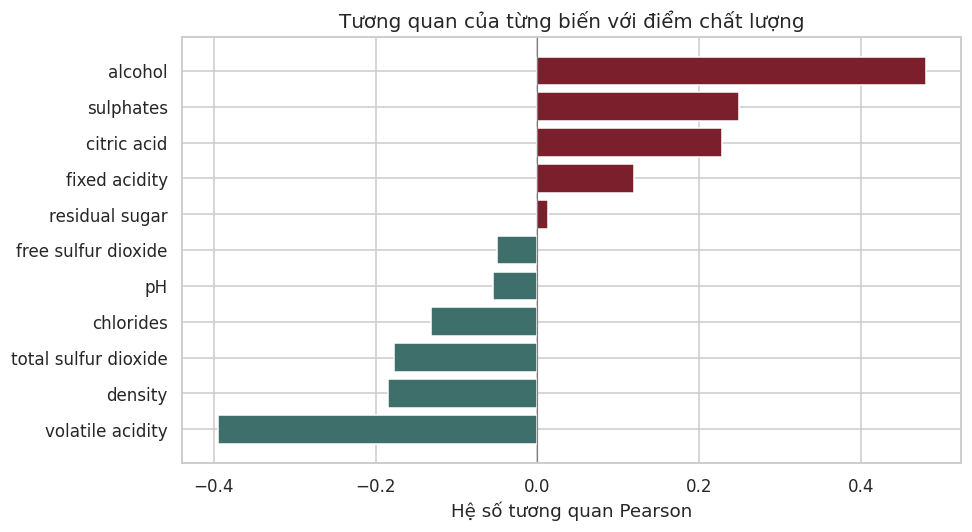

In [13]:
corr_q = wine.corr()["quality"].drop("quality").sort_values()
plt.figure(figsize=(9,5))
colors = [TEAL if v < 0 else WINE for v in corr_q.values]
plt.barh(corr_q.index, corr_q.values, color=colors)
plt.axvline(0, color="gray", lw=0.8)
plt.title("Tương quan của từng biến với điểm chất lượng")
plt.xlabel("Hệ số tương quan Pearson")
plt.tight_layout()
plt.show()

## 9. Kết luận
1. **Cấu trúc:** dữ liệu sạch sau khi loại trùng, không có giá trị thiếu; 11 biến hóa lý số + biến mục tiêu `quality` (3–8).
2. **Phân bố mục tiêu:** mất cân bằng lớp mạnh, tập trung ở điểm 5–6.
3. **Yếu tố tỷ lệ thuận với chất lượng:** `alcohol` (mạnh nhất), `sulphates`, `citric acid`.
4. **Yếu tố tỷ lệ nghịch:** `volatile acidity` (mạnh nhất), `total sulfur dioxide`, `density`.
5. **Ngoại lai:** xuất hiện ở nhiều biến — cần cân nhắc xử lý trước khi xây mô hình phân loại.